In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import random
import math
from statsmodels.tsa.stattools import acf

def get_subsys_masks(channel_names):    
    # Create boolean masks for each subsystem
    subsys_counts = {}
    subsys_masks = {}
    n = len(channel_names)
    for i, name in enumerate(channel_names):
        key = name[3:6]

        subsys_counts[key] = subsys_counts.get(key, 0) + 1

        if key not in subsys_masks:
            subsys_masks[key] = np.zeros(n, dtype=bool)
        subsys_masks[key][i] = True
    print(subsys_counts)
    return subsys_masks

values = torch.load('./values/GWSUS.pt')
preds = values[0]
ground_truth = values[1]

gt = pd.read_parquet('../data/GW/test_stand_CTWS.parquet')
train = pd.read_parquet('../data/GW/train_stand.parquet')
full_channel_names = list(gt.keys())

subsys_masks = get_subsys_masks(full_channel_names)
gtSUB = gt.iloc[:,subsys_masks['SUS']]

spec_ch_names = list(gtSUB.keys())

{'ALS': 2, 'ASC': 77, 'CAL': 2, 'HPI': 88, 'IMC': 42, 'ISI': 106, 'LSC': 25, 'OMC': 4, 'PEM': 141, 'PSL': 9, 'SQZ': 45, 'SUS': 238, 'TCS': 4, 'ack': 1}


In [19]:
print(gt.shape)

(303104, 784)


In [26]:
indices = []
total_time_len = len(gt)
slide_win = 100
segment_length = 2048
rng = range(slide_win, total_time_len)
        
for i in rng:
    start_ft_seg = (i - slide_win) // segment_length   # Here check for each index i if the target and the window used to predict it are in the same segment
    target_seg = i // segment_length

    if start_ft_seg == target_seg:
        indices.append(i)

print(len(indices))
print(total_time_len)

n = len(indices)
n_channels = gt.shape[1]

features = np.empty((n, slide_win, n_channels))

for j, idx in enumerate(indices):
    features[j] = gt.iloc[idx-slide_win:idx, :]

288304
303104


In [21]:
print(n_channels)

784


In [ ]:
import torch
from torch.utils.data import Dataset
class TimeDataset2(Dataset):
    def __init__(self, raw_data, edge_index, mode='train', config=None, segment_length=2048):
        data = np.array(raw_data[:-1], dtype=np.float32)
        raw_data = torch.from_numpy(data)  # features
        labels = np.array(raw_data[-1], dtype=np.float32)
        labels = torch.from_numpy(labels)    # labels
        edge_index = edge_index.long()
        mode = mode
        config = config
        segment_length = segment_length

        slide_win, slide_stride = [config[k] for k in ['slide_win', 'slide_stride']]
        node_num, total_time_len = raw_data.shape

        # Precompute valid indices (optional, especially if segments exist)
        valid_indices = _compute_valid_indices()

    def _compute_valid_indices(self):
        indices = []
        rng = range(slide_win, total_time_len, slide_stride) \
            if mode == 'train' else range(slide_win, total_time_len)
        
        for i in rng:
            start_ft_seg = (i - slide_win) // segment_length   # Here check for each index i if the target and the window used to predict it are in the same segment
            target_seg = i // segment_length

            if start_ft_seg == target_seg:
                indices.append(i)

        return indices

    def __len__(self):
        return len(valid_indices)

    def __getitem__(self, idx):
        i = valid_indices[idx]  # actual time index for this sample

        # compute window on-the-fly
        ft = raw_data[:, i - slide_win:i]    # shape: [nodes, slide_win]
        tar = raw_data[:, i]                      # shape: [nodes]
        label = labels[i]                          # scalar

        return ft, tar, label, edge_index

ModuleNotFoundError: No module named 'datasets'

In [2]:
params = torch.load('../pretrained/GW/best_05|15-09:59:01_IMC_100s_k15.pt')

keys = list(params.keys())

for key in keys:
    print(key,':',  params[key].shape)

embedding.weight : torch.Size([42, 128])
bn_outlayer_in.weight : torch.Size([128])
bn_outlayer_in.bias : torch.Size([128])
bn_outlayer_in.running_mean : torch.Size([128])
bn_outlayer_in.running_var : torch.Size([128])
bn_outlayer_in.num_batches_tracked : torch.Size([])
gnn_layers.0.gnn.att_i : torch.Size([1, 1, 128])
gnn_layers.0.gnn.att_j : torch.Size([1, 1, 128])
gnn_layers.0.gnn.att_em_i : torch.Size([1, 1, 128])
gnn_layers.0.gnn.att_em_j : torch.Size([1, 1, 128])
gnn_layers.0.gnn.bias : torch.Size([128])
gnn_layers.0.gnn.lin.weight : torch.Size([128, 100])
gnn_layers.0.gnn2.att_i : torch.Size([1, 1, 128])
gnn_layers.0.gnn2.att_j : torch.Size([1, 1, 128])
gnn_layers.0.gnn2.att_em_i : torch.Size([1, 1, 128])
gnn_layers.0.gnn2.att_em_j : torch.Size([1, 1, 128])
gnn_layers.0.gnn2.bias : torch.Size([128])
gnn_layers.0.gnn2.lin.weight : torch.Size([128, 128])
gnn_layers.0.bn.weight : torch.Size([128])
gnn_layers.0.bn.bias : torch.Size([128])
gnn_layers.0.bn.running_mean : torch.Size([128

In [ ]:
att_weight = 

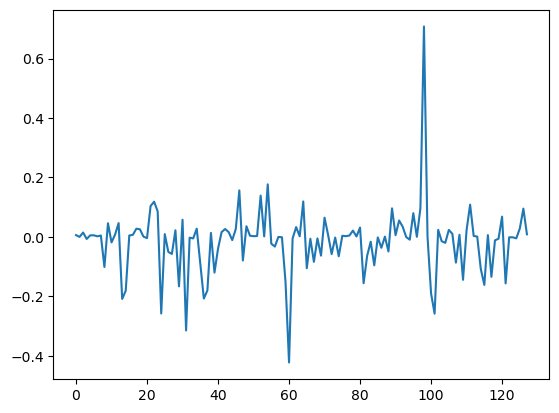

In [3]:
#print(val['gnn_layers.0.gnn.att_i'] == val['gnn_layers.0.gnn2.att_i'])
plt.plot(val['gnn_layers.0.gnn.att_i'][0,0,:].cpu())